In [1]:
import subprocess
import sys
import re
import os
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp

### Compile, set up and run the code

In [ ]:
controlEvoFile = "evo-control.dat"

structFileName = "struct-dev.dat"
evolveFileName = "evo-dev.dat"
runcmd = f"./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -inject 1.417e31 1000 -struct {structFileName} -wr {evolveFileName}"


In [3]:
result = subprocess.run(
"make clean", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    raise OSError("OS could not handle make clean")
print("Cleaned")

result = subprocess.run(
"make", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError(f"Could not make:{result.stderr}")
print("Made")

"""
result = subprocess.run(
runcmd, 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)
"""


Cleaned
Made


'\nresult = subprocess.run(\nruncmd, \nshell=True, \ncapture_output=True, \ntext=True,\ntimeout=300\n)\nif result.returncode != 0:\n    print(result.stdout)\n    raise OSError("Runtime error")\nprint("Executed with exit code 0")\nprint(result.stdout)\n'

In [ ]:
#multiprocessing

def run_sims(energy):
    magstr = str(energy).replace(".","-")
    runcmd = f"./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -inject {energy} 1000 -struct {structFileName} -wr {evolveFileName}"
    print(runcmd)
    result = subprocess.run(
    runcmd, 
    shell=True, 
    capture_output=True, 
    text=True,
    timeout=500
    )
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)
impact_energies = []
with mp.Pool(processes=mp.cpu_count()-1) as pool:
    all_results = pool.map(run_sims, impact_energies)

Executed with exit code 0
g++ -O3 src/PlanetSolver.cpp src/constants.cpp src/EOS.cpp src/Planet.cpp src/HHeComp.cpp -o PlanetSolver
g++ -O3 src/EqGen.cpp src/constants.cpp src/EOS.cpp src/HHeComp.cpp -o EqGen

./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1e1 -struct struct-dev.dat -wr evo-dev.dat-1./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1e1.75 -struct struct-dev.dat -wr evo-dev.dat-1-75./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1e1.5 -struct struct-dev.dat -wr evo-dev.dat-1-5./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1e2.0 -struct struct-dev.dat -wr evo-dev.dat-2-0./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1e2.25 -struct struct-dev.dat -wr evo-dev.dat-2-25./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1e2.

### View the modeled evolution

In [ ]:
input_col_names = ['Age', 'Atmospheric Entropy', 'Radius', 'Mass', 'delta_M', 'AMF', 'T_eff']
evodfs = {}
for factor in impact_energies:
    factor_filename = str(factor).replace(".","-")
    efile = evolveFileName + f"-{factor_filename}"
    with open(efile, 'r') as file:
            lines = file.readlines()
    data_start_idx = None
    header_lines = []
        
    for i, line in enumerate(lines):
        line = line.strip()
        # Look for the column headers
        if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
            data_start_idx = i+1 #skips heading column
            break
        else:
            header_lines.append(line)

    evodf = pd.read_table(efile, skiprows=data_start_idx, names=input_col_names, sep=" ")
    print(factor)
    evodfs[factor] = evodf

# Get control file
with open(controlEvoFile, 'r') as file:
        lines = file.readlines()
data_start_idx = None
header_lines = []
    
for i, line in enumerate(lines):
    line = line.strip()
    # Look for the column headers
    if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
        data_start_idx = i+1 #skips heading column
        break
    else:
        header_lines.append(line)

dfcontrol = pd.read_table(controlEvoFile, skiprows=data_start_idx, names=input_col_names, sep=" ")

1
1.5
1.75
2.0
2.25
2.5
2.75
3.0
3.25


In [ ]:
dfcontrol

,Age,Atmospheric Entropy,Radius,Mass,delta_M,AMF,T_eff
0,0.000000,8.40000,9.41637,8.00012,0.000000,0.100000,0.0000
1,0.095483,8.39000,5.48765,8.00004,0.000074,0.099992,368.5350
2,0.383932,8.38000,5.44776,8.00000,0.000048,0.099986,365.8620
3,0.684212,8.37000,5.40857,7.99995,0.000048,0.099981,363.2100
4,0.996787,8.36000,5.37015,7.99990,0.000049,0.099975,360.5700
...,...,...,...,...,...,...,...
286,13687.400000,6.20750,2.74908,7.76346,0.000013,0.072565,72.6874
287,13787.400000,6.20430,2.74778,7.76345,0.000013,0.072563,72.5281
288,13887.400000,6.20113,2.74646,7.76343,0.000013,0.072562,72.3087
289,13987.400000,6.19799,2.74509,7.76342,0.000013,0.072560,72.1818


In [ ]:
sns.set_theme({"axes.spines.left": True, "axes.spines.bottom": True, 
          "axes.spines.top": False, "axes.spines.right": False})
evodfs.keys()

dict_keys([1, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25])

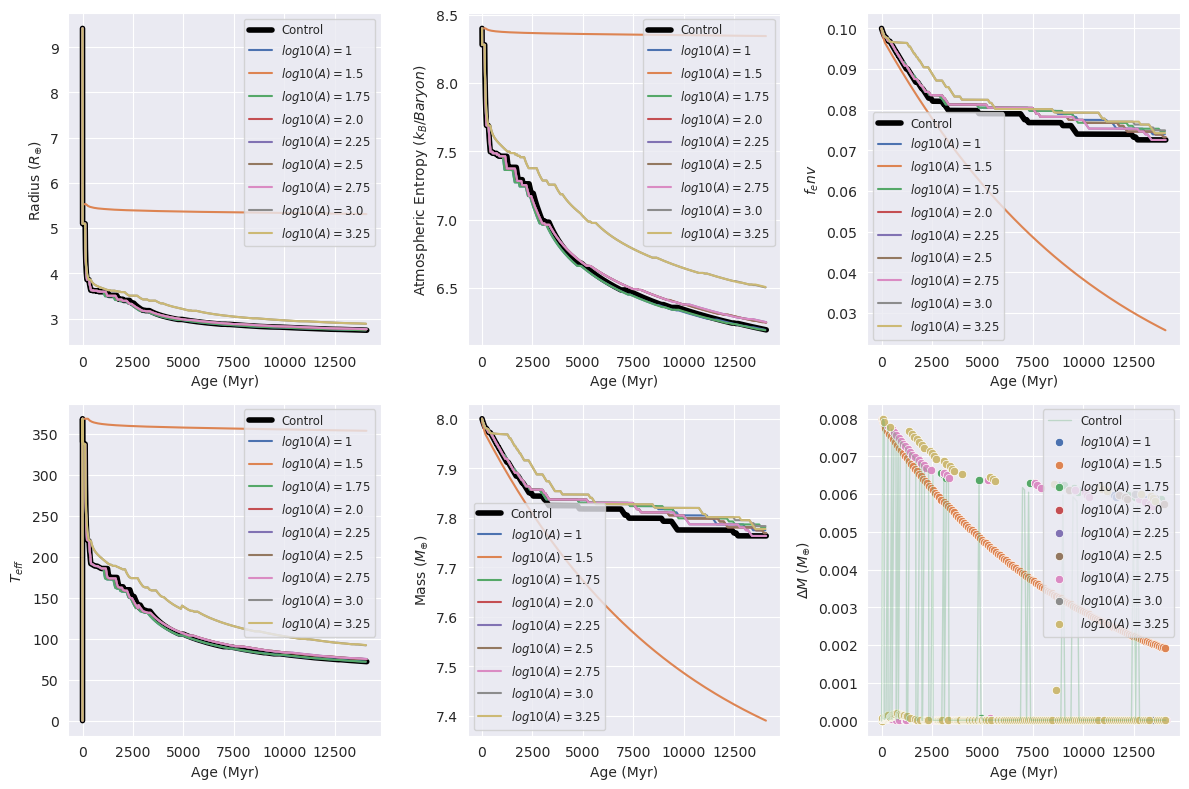

In [ ]:
f, axes = plt.subplots(2, 3, figsize=(12, 8))
axs = axes.flatten()

sns.lineplot(data=dfcontrol, x="Age", y="Radius", ax=axs[0], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x='Age', y="Radius", ax=axs[0], label=rf'$log10(A)=${key}')
axs[0].legend(fontsize='small')
axs[0].set_ylabel(r"Radius ($R_{\oplus}$)")

sns.lineplot(data=dfcontrol, x="Age", y="Atmospheric Entropy", ax=axs[1], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="Atmospheric Entropy", ax=axs[1], label=rf'$log10(A)=${key}')
axs[1].legend(fontsize='small')
axs[1].set_ylabel(r"Atmospheric Entropy ($k_B/Baryon$)")

sns.lineplot(data=dfcontrol, x="Age", y="AMF", ax=axs[2], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="AMF", ax=axs[2], label=rf'$log10(A)=${key}')
axs[2].legend(fontsize='small')
axs[2].set_ylabel(r"$f_env$")

sns.lineplot(data=dfcontrol, x="Age", y="T_eff", ax=axs[3], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="T_eff", ax=axs[3], label=rf'$log10(A)=${key}')
axs[3].legend(fontsize='small')
axs[3].set_ylabel(r"$T_{eff}$")

sns.lineplot(data=dfcontrol, x="Age", y="Mass", ax=axs[4], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="Mass", ax=axs[4], label=rf'$log10(A)=${key}')
axs[4].legend(fontsize='small')
axs[4].set_ylabel(r"Mass ($M_{\oplus}$)")

sns.lineplot(data=dfcontrol, x="Age", y="delta_M", ax=axs[5], color='g', alpha=0.3, label='Control', lw=1)
for key, df in evodfs.items():
    sns.scatterplot(data=df, x="Age", y="delta_M", ax=axs[5], label=rf'$log10(A)=${key}')
axs[5].legend(fontsize='small')
axs[5].set_ylabel(r"$\Delta M$ ($M_{\oplus}$)")

for ax in axs:
    ax.set_xlabel('Age (Myr)')
f.tight_layout()